In [9]:
# ===== Setup: environment, installs, imports =====
import subprocess, sys, os, random, math, re, shutil, zipfile
subprocess.call([sys.executable, "-m", "pip", "install", "-q", "torch>=2.2.0", "torchvision>=0.17.0", "pandas>=2.1.0", "numpy>=1.25.0", "matplotlib>=3.7.0", "tqdm>=4.66.0", "gradio>=4.44.0"])

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

def set_seed(seed=42):
    """Seed Python, NumPy, and Torch for reproducibility on CPU/GPU."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed);
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [10]:
# ===== Load dataset ZIP from Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# <<< EDIT THIS PATH >>>
ZIP_ON_DRIVE = "/content/drive/MyDrive/question02.zip"

EXTRACT_DIR = "/content/shakespeare_plays"
if os.path.exists(EXTRACT_DIR): shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_ON_DRIVE, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Example files:", sorted(os.listdir(EXTRACT_DIR))[:10])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted to: /content/shakespeare_plays
Example files: ['Shakespeare_data.csv', 'alllines.txt', 'william-shakespeare-black-silhouette.jpg']


In [11]:
# ===== Make one big text corpus (robust to TXT or CSV) =====
def load_corpus(root: str) -> str:
    """
    Create a single text string from dataset directory.
    Supports:
      - multiple .txt files (concatenated)
      - CSV with a column likely holding lines (tries common column names)
    Filters obvious stage directions in brackets to keep training cleaner.
    """
    texts = []
    for dirpath, _, files in os.walk(root):
        for f in files:
            p = os.path.join(dirpath, f)
            if f.lower().endswith(".txt"):
                try:
                    t = open(p, "r", encoding="utf-8", errors="ignore").read()
                    texts.append(t)
                except Exception:
                    pass
            elif f.lower().endswith(".csv"):
                try:
                    df = pd.read_csv(p)
                    for col in ["text","line","playerline","PlayerLine","dialogue","content"]:
                        if col in df.columns:
                            s = "\n".join([str(x) for x in df[col].dropna().tolist()])
                            texts.append(s)
                            break
                except Exception:
                    pass
    full = "\n\n".join(texts)
    full = re.sub(r"\[[^\]]+\]", " ", full)   # remove [Stage Directions]
    full = re.sub(r"\s+", " ", full).strip()
    return full

corpus = load_corpus(EXTRACT_DIR)
print("Corpus chars:", len(corpus))
print("Preview:", corpus[:500])
assert len(corpus) > 10000, "Corpus seems too small—check your ZIP content/path."

Corpus chars: 8930692
Preview: "ACT I" "SCENE I. London. The palace." "Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORELAND, SIR WALTER BLUNT, and others" "So shaken as we are, so wan with care," "Find we a time for frighted peace to pant," "And breathe short-winded accents of new broils" "To be commenced in strands afar remote." "No more the thirsty entrance of this soil" "Shall daub her lips with her own children's blood," "Nor more shall trenching war channel her fields," "Nor bruise her flowerets with the ar


In [12]:
# ===== Tokenization, vocab, dataset split =====
def basic_word_tokenize(text: str):
    """Lowercase, keep apostrophes within words, split on non-letters/digits/apostrophes."""
    t = text.lower()
    t = re.sub(r"[^a-z0-9']+", " ", t)
    toks = [w for w in t.strip().split() if w]
    return toks

tokens = basic_word_tokenize(corpus)
print("Tokens:", len(tokens), "Unique:", len(set(tokens)))

from collections import Counter
min_freq = 2
freqs = Counter(tokens)
itos = ["<pad>","<unk>"]
for w, c in freqs.most_common():
    if c >= min_freq: itos.append(w)
stoi = {w:i for i,w in enumerate(itos)}
vocab_size = len(itos)

def encode(words):
    """Map list of tokens to ids, using <unk> for OOV."""
    unk = stoi["<unk>"]
    return [stoi.get(w, unk) for w in words]

ids = encode(tokens)
print("Vocab size:", vocab_size)

# Build supervised windows (sequence_length -> next_token)
seq_len = 12
X_ids, y_ids = [], []
for i in range(len(ids) - seq_len):
    X_ids.append(ids[i:i+seq_len])
    y_ids.append(ids[i+seq_len])

X_ids = np.array(X_ids, dtype=np.int64)
y_ids = np.array(y_ids, dtype=np.int64)
print("Supervised samples:", len(X_ids))

# Train/Val/Test (80/10/10)
n = len(X_ids)
i_tr = int(n*0.8)
i_va = int(n*0.9)
X_tr, y_tr = X_ids[:i_tr], y_ids[:i_tr]
X_va, y_va = X_ids[i_tr:i_va], y_ids[i_tr:i_va]
X_te, y_te = X_ids[i_va:], y_ids[i_va:]
len(X_tr), len(X_va), len(X_te)

Tokens: 1639948 Unique: 25569
Vocab size: 25571
Supervised samples: 1639936


(1311948, 163994, 163994)

In [14]:
# ===== Torch dataset & loaders =====
class NextWordDataset(Dataset):
    """Return (seq_ids, next_id) pairs for next-word prediction."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 256
train_ds = NextWordDataset(X_tr, y_tr)
val_ds   = NextWordDataset(X_va, y_va)
test_ds  = NextWordDataset(X_te, y_te)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

In [15]:
# ===== LSTM next-word model =====
class NextWordLSTM(nn.Module):
    """
    Word-level next-token predictor with Embedding + LSTM + Linear.
    Args:
        vocab_size: number of tokens
        emb_dim: embedding dimension
        hidden_dim: LSTM hidden size
        num_layers: LSTM layers
        dropout: dropout after LSTM
    """
    def __init__(self, vocab_size:int, emb_dim:int=256, hidden_dim:int=512, num_layers:int=2, dropout:float=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        h = out[:, -1, :]
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

Epoch 1: tr_loss=6.5194  va_loss=6.0204  va_ppl=411.74  va@1=0.098  va@5=0.234


Epoch 2: tr_loss=5.9000  va_loss=5.6774  va_ppl=292.20  va@1=0.113  va@5=0.264


Epoch 3: tr_loss=5.5362  va_loss=5.4035  va_ppl=222.19  va@1=0.123  va@5=0.284


Epoch 4: tr_loss=5.2275  va_loss=5.1492  va_ppl=172.29  va@1=0.133  va@5=0.304


Epoch 5: tr_loss=4.9422  va_loss=4.9212  va_ppl=137.17  va@1=0.142  va@5=0.320


Epoch 6: tr_loss=4.6751  va_loss=4.6980  va_ppl=109.72  va@1=0.152  va@5=0.340


Epoch 7: tr_loss=4.4456  va_loss=4.5010  va_ppl=90.11  va@1=0.166  va@5=0.361


Epoch 8: tr_loss=4.2477  va_loss=4.3280  va_ppl=75.79  va@1=0.181  va@5=0.384


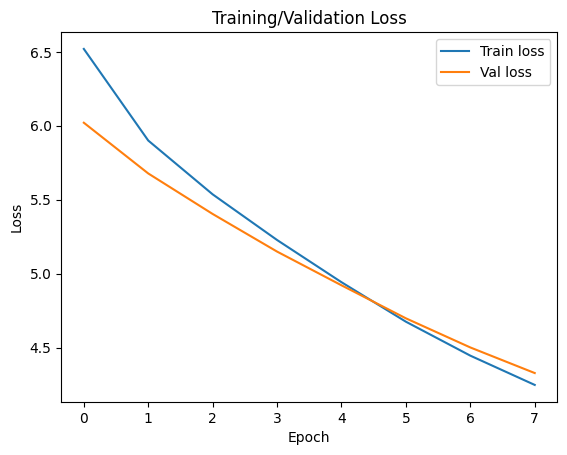

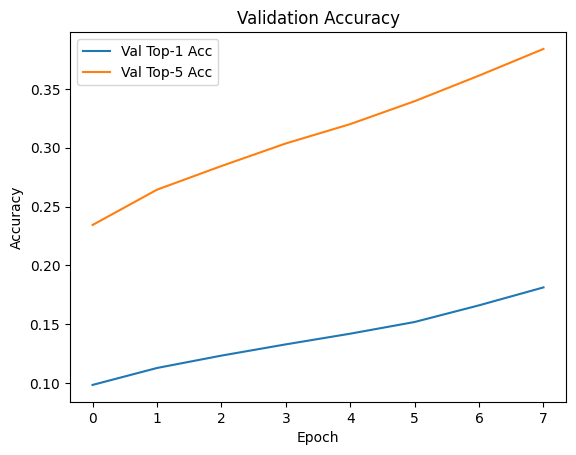

Test: loss=4.3516  ppl=77.60  top1=0.180  top5=0.381


In [16]:
# ===== Training utilities =====
def topk_acc(logits, y, k=1):
    """Compute top-k accuracy for logits (B,V) against targets (B)."""
    topk = logits.topk(k, dim=1).indices
    correct = (topk == y.unsqueeze(1)).any(dim=1).float().mean().item()
    return correct

@torch.no_grad()
def evaluate(model, loader, device):
    """
    Evaluate model on a loader.
    Returns dict with 'loss', 'ppl', 'top1', 'top5'.
    """
    model.eval()
    ce = nn.CrossEntropyLoss()
    tot_loss, tot_n, t1, t5 = 0.0, 0, 0.0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = ce(logits, yb)
        b = yb.size(0)
        tot_loss += loss.item() * b
        tot_n += b
        t1 += topk_acc(logits, yb, k=1) * b
        t5 += topk_acc(logits, yb, k=5) * b
    avg_loss = tot_loss / tot_n
    ppl = math.exp(min(20, avg_loss))
    return {"loss": avg_loss, "ppl": ppl, "top1": t1/tot_n, "top5": t5/tot_n}

def train_model(hparams):
    """
    Train LSTM with given hyperparameters.
    hparams expects: emb_dim, hidden_dim, num_layers, dropout, lr, epochs
    Returns model and history dict.
    """
    model = NextWordLSTM(vocab_size, **{k:hparams[k] for k in ["emb_dim","hidden_dim","num_layers","dropout"]}).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=hparams["lr"])
    ce = nn.CrossEntropyLoss()
    hist = {"tr_loss": [], "va_loss": [], "va_ppl": [], "va_top1": [], "va_top5": []}
    best_state, best_va = None, 1e9

    for ep in range(1, hparams["epochs"]+1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in tqdm(train_dl, leave=False, desc=f"Epoch {ep}/{hparams['epochs']}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = ce(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += loss.item() * yb.size(0)
            n += yb.size(0)

        tr_loss = running / n
        va = evaluate(model, val_dl, DEVICE)
        hist["tr_loss"].append(tr_loss)
        hist["va_loss"].append(va["loss"])
        hist["va_ppl"].append(va["ppl"])
        hist["va_top1"].append(va["top1"])
        hist["va_top5"].append(va["top5"])

        if va["loss"] < best_va:
            best_va = va["loss"]
            best_state = {k:v.detach().cpu() for k,v in model.state_dict().items()}
        print(f"Epoch {ep}: tr_loss={tr_loss:.4f}  va_loss={va['loss']:.4f}  va_ppl={va['ppl']:.2f}  va@1={va['top1']:.3f}  va@5={va['top5']:.3f}")

    if best_state: model.load_state_dict(best_state, strict=True)
    return model, hist

# Base hyperparameters (you can sweep later)
hparams = dict(emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2, lr=2e-3, epochs=8)
model, history = train_model(hparams)

# Curves (Loss and Top-1)
plt.figure()
plt.plot(history["tr_loss"], label="Train loss")
plt.plot(history["va_loss"], label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training/Validation Loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(history["va_top1"], label="Val Top-1 Acc")
plt.plot(history["va_top5"], label="Val Top-5 Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Validation Accuracy"); plt.legend(); plt.show()

# Test metrics
test = evaluate(model, test_dl, DEVICE)
print(f"Test: loss={test['loss']:.4f}  ppl={test['ppl']:.2f}  top1={test['top1']:.3f}  top5={test['top5']:.3f}")

In [17]:
# ===== Inference: next-word suggestions =====
idx_to_word = {i:w for w,i in enumerate(stoi.keys())}  # wrong! fix mapping below
# fix mapping using itos we built earlier
idx_to_word = {i:w for i,w in enumerate(itos)}

def encode_text(text: str, max_len:int=12):
    """
    Tokenize and encode a partial sentence into a fixed-length window.
    Left-pad with <pad> if needed; truncate from the left if too long.
    """
    toks = basic_word_tokenize(text)
    ids_seq = encode(toks)
    if len(ids_seq) < max_len:
        ids_seq = [0]*(max_len-len(ids_seq)) + ids_seq
    else:
        ids_seq = ids_seq[-max_len:]
    return torch.tensor([ids_seq], dtype=torch.long)

@torch.no_grad()
def suggest_next_words(prefix: str, topk:int=5):
    """
    Return list of (word, prob) suggestions for the next word given prefix.
    """
    model.eval()
    xb = encode_text(prefix, max_len=seq_len).to(DEVICE)
    logits = model(xb)
    probs = torch.softmax(logits, dim=-1)[0]
    vals, idxs = probs.topk(topk)
    suggestions = [(idx_to_word[i], float(v)) for v, i in zip(vals.tolist(), idxs.tolist())]
    return suggestions

print(suggest_next_words("to be, or not to", topk=5))

[('be', 0.12905196845531464), ('the', 0.0649871975183487), ('hide', 0.03881719335913658), ('see', 0.027283696457743645), ('me', 0.01838519051671028)]


In [18]:
# ===== Live web UI: type → get next-word suggestions =====
import gradio as gr

def ui_suggest(prefix):
    """
    Gradio wrapper that returns a ranked list of next-word suggestions and a completed sentence.
    """
    if not prefix or not prefix.strip():
        return "Type a partial sentence...", ""
    sugg = suggest_next_words(prefix, topk=5)
    lines = [f"{i+1}. {w}  (p={p:.3f})" for i,(w,p) in enumerate(sugg)]
    best = sugg[0][0] if sugg else ""
    completed = prefix.rstrip() + " " + best
    return "\n".join(lines), completed

with gr.Blocks() as demo:
    gr.Markdown("## Shakespeare LSTM: Next-Word Suggestions")
    inp = gr.Textbox(label="Type your partial sentence:", placeholder="e.g., to be, or not to", lines=1)
    out1 = gr.Textbox(label="Top-5 suggestions", lines=6)
    out2 = gr.Textbox(label="Auto-completed (top-1)", lines=2)
    inp.change(ui_suggest, inputs=inp, outputs=[out1, out2])
    gr.Markdown("Suggestions update automatically as you type.")

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c063cdeb38437f6e1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
# ===== Tiny hyperparameter sweep (few epochs for speed) =====
def quick_train_eval(emb_dim, hidden_dim, num_layers, dropout, lr, epochs=3):
    """
    Fast training run to compare validation perplexity and accuracy across settings.
    """
    h = dict(emb_dim=emb_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, lr=lr, epochs=epochs)
    m, hist = train_model(h)
    va = dict(loss=hist["va_loss"][-1], ppl=hist["va_ppl"][-1], top1=hist["va_top1"][-1], top5=hist["va_top5"][-1])
    return {**h, **va}

grid = [
    (128, 256, 1, 0.1, 3e-3),
    (256, 512, 2, 0.2, 2e-3),
    (300, 600, 2, 0.3, 1.5e-3),
]
rows = []
for emb, hid, layers, drop, lr in grid:
    rows.append(quick_train_eval(emb, hid, layers, drop, lr, epochs=3))

sweep_df = pd.DataFrame(rows)
display(sweep_df.sort_values("ppl"))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Epoch 1: tr_loss=6.0078  va_loss=5.5306  va_ppl=252.28  va@1=0.119  va@5=0.279


Epoch 2: tr_loss=5.2719  va_loss=5.1417  va_ppl=171.01  va@1=0.133  va@5=0.306


Epoch 3: tr_loss=4.8084  va_loss=4.8584  va_ppl=128.82  va@1=0.149  va@5=0.334


Epoch 1: tr_loss=6.3623  va_loss=5.9334  va_ppl=377.42  va@1=0.101  va@5=0.242


...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['num_layers']
  ys = series['dropout']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_27.sort_values('num_layers', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('num_layers')
_ = plt.ylabel('dropout')

from matplotlib import pyplot as plt
_df_28['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_29['emb_dim'].plot(kind='line', figsize=(8, 4), title='emb_dim')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_30['hidden_dim'].plot(kind='line', figsize=(8, 4), title='hidden_dim')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_31['num_layers'].plot(kind='line', figsize=(8, 4), title='num_layers')
plt.gca().spines[['top', 'right']].set_visible(False)

In [20]:
# ===== Save best model to Drive =====
SAVE_PATH = "/content/drive/MyDrive/shakespeare_lstm_nextword.pt"
torch.save({"state_dict": model.state_dict(),
            "hparams": hparams,
            "vocab": {"itos": itos, "seq_len": seq_len}}, SAVE_PATH)
print("Saved:", SAVE_PATH)

Saved: /content/drive/MyDrive/shakespeare_lstm_nextword.pt
